Finding the formation efficency

In [7]:
#imports!

# let's import things
import h5py as h5 
import pandas as pd
from astropy.table import Table
from astropy import units as u
from astropy import constants as const
import numpy as np
import matplotlib.pyplot as plt
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
import sys
import os
from scipy import stats
import seaborn as sns
import matplotlib as mpl
import tol_colors as tc

# Add the subdir to sys.path for our created scripts
sys.path.append('/home/msantiago/research_work/useful_py_scripts/')
sys.path.append('/home/msantiago/research_work/making_figures/paper_figures/')

# Now you can import the module
import useful_fncs
import utils_from_others
import figure_utils

# import for axes labels 
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

In [2]:
# let's read in our files 

## NSNS optimized run

# let's first look at the NSNS_output
pathToH5_NSNS = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS  = h5.File(pathToH5_NSNS, "r")

DCOs_NSNS = Data_NSNS['BSE_Double_Compact_Objects'] # getting the DCO objects

DATA_SPS = Data_NSNS['BSE_System_Parameters']
# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

In [3]:
# print(Data_NSNS['Run_Details']['initial-mass-min'][...].squeeze())
# print(Data_NSNS['Run_Details']['initial-mass-max'][...].squeeze())


In [4]:
print(Data_NSNS['Run_Details']['metallicity-min'][()][0])
metallicity_min = Data_NSNS['Run_Details']['metallicity-min'][()][0]


for param in ['semi-major-axis-max', 'semi-major-axis-min', 'minimum-secondary-mass', 'mass-ratio-min', 'mass-ratio-max',  'initial-mass-max', 'initial-mass-min']:
    param_val = Data_NSNS['Run_Details'][param][()][0]
    print(param, ' = ', param_val)

0.0001
semi-major-axis-max  =  1000.0
semi-major-axis-min  =  0.01
minimum-secondary-mass  =  0.1
mass-ratio-min  =  0.01
mass-ratio-max  =  1.0
initial-mass-max  =  150.0
initial-mass-min  =  5.0


In [5]:
setllar_typesDCO_1 = DCOs_NSNS["Stellar_Type(1)"][()]
setllar_typesDCO_2 = DCOs_NSNS["Stellar_Type(2)"][()]

In [6]:
np.unique(setllar_typesDCO_1)

array([11, 12, 13, 14], dtype=int32)

In [7]:
# we want to find how many merging NSNS systems there are
Merges_Hubble_Time = Data_NSNS['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
condition_mergers = Merges_Hubble_Time == True

# # times (these should be in Myr)
# lifetimes_all = DCOs_NSNS['Time'][()]
# lifetimes = lifetimes_all[DCO_mask_NSNS]

# col_times_all = DCOs_NSNS['Coalescence_Time'][()]
# col_times = col_times_all[DCO_mask_NSNS]

# # this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
# delay_times = lifetimes + col_times

# hubble_time = 13.9e3 # this is Myrs
# condition_mergers = delay_times < hubble_time
# mergers = np.sum(condition_mergers)

In [8]:
# selecting for NSNS
stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1_merged = stellar_types_all_1[DCO_mask_NSNS*condition_mergers]
# stellar_types_1_merged = stellar_types_1[condition_mergers]

stellar_types_all_2 = DCOs_NSNS['Stellar_Type(2)'][()]
stellar_types_2_merged = stellar_types_all_2[DCO_mask_NSNS*condition_mergers]
# stellar_types_2_merged = stellar_types_2[condition_mergers]

In [9]:
# making sure we are rpesenting the true universe
mixture_weights_all = DCOs_NSNS['mixture_weight'][()]
mixtrue_weights_merged = mixture_weights_all[DCO_mask_NSNS*condition_mergers]
# mixtrue_weights_merged = mixture_weights[condition_mergers]

In [10]:
# now we want to figure out how many NSNS systems merge within a hubble time

NSNS_systems_bool = np.logical_and(stellar_types_1_merged==13, stellar_types_2_merged==13)
np.sum(NSNS_systems_bool)


np.int64(162834)

In [11]:
###################################################
# New version of analytical calculation
###################################################
def analytical_star_forming_mass_per_binary_using_kroupa_imf(
        m1_min, m1_max, m2_min, fbin=1., imf_mass_bounds=[0.01,0.08,0.5,200]
):
    """
    Analytical computation of the mass of stars formed per binary star formed within the
    [m1 min, m1 max] and [m2 min, ..] rage,
    using the Kroupa IMF:

        p(M) \propto M^-0.3 for M between m1 and m2
        p(M) \propto M^-1.3 for M between m2 and m3;
        p(M) = alpha * M^-2.3 for M between m3 and m4;

    m1_min, m1_max are the min and max sampled primary masses
    m2_min is the min sampled secondary mass

    This function further assumes a flat mass ratio distribution with qmin = m2_min/m1, and  m2_max = m1_max
    Lieke base on Ilya Mandel's derivation
    """
    # Kroupa IMF 
    m1, m2, m3, m4 = imf_mass_bounds
    continuity_constants = [1./(m2*m3), 1./(m3), 1.0]  
    IMF_powers = [-0.3, -1.3, -2.3]  

    if m1_min < m3:
        raise ValueError(f"This analytical derivation requires IMF break m3  < m1_min ({m3} !< {m1_min})")
    if m1_min > m1_max:
        raise ValueError(f"Minimum sampled primary mass cannot be above maximum sampled primary mass: m1_min ({m1_min} !<  m1_max {m1_max})")
    if m1_max > m4:
        raise ValueError(f"Maximum sampled primary mass cannot be above maximum mass of Kroupa IMF:  m1_max ({m1_max} !<  m4 {m4})")
    
    # normalize IMF over the complete mass range:
    alpha = (-(m4**(-1.3)-m3**(-1.3))/1.3 - (m3**(-0.3)-m2**(-0.3))/(m3*0.3) + (m2**0.7-m1**0.7)/(m2*m3*0.7))**(-1)
    # print('alpha', alpha)

    # we want to compute M_stellar_sys_in_universe / N_binaries_in_COMPAS
    #  = N_binaries_in_universe/N_binaries_in_COMPAS * N_stellar_sys_in_universe/N_binaries_in_universe * M_stellar_sys_in_universe/N_stellar_sys_in_universe
    #  = 1/fint * 1/fbin * average mass of a stellar system in the Universe

    # fint =  N_binaries_in_COMPAS/N_binaries_in_universe: fraction of binaries that COMPAS simulates
    fint = -alpha / 1.3 * (m1_max ** (-1.3) - m1_min ** (-1.3)) + alpha * m2_min / 2.3 * (m1_max**(-2.3) - m1_min **(-2.3))


    # Next for N_stellar_sys_in_universe/N_binaries_in_universe * M_stellar_sys_in_universe/N_stellar_sys_in_universe
    # N_stellar_sys_in_universe/N_binaries_in_universe = the binary fraction 
    # fbin edges and values are chosen to approximately follow Figure 1 from Offner et al. (2023)
    binary_bin_edges = [m1, 0.08, 0.5, 1, 10, m4]    
    if isinstance(fbin, (int, float)):
        # Constant binary fraction
        binaryFractions = [fbin] * 5
    else:
        # Variable binary fraction with mass
        binaryFractions = [0.1, 0.225, 0.5, 0.8, 1.0] 


    # M_stellar_sys_in_universe/N_stellar_sys_in_universe = average mass of a stellar system in the Universe,
    # we are computing 1/fbin * M_stellar_sys_in_universe/N_stellar_sys_in_universe, skipping steps this leads to:
    # int_A^B (1/fb(m1) + 0.5) m1 P(m1) dm1. 
    # This is a double piecewise integral, i.e. pieces over the binary fraction bins and IMF mass bins.
    piece_wise_integral = 0

    # For every binary fraction bin
    for i in range(len(binary_bin_edges) - 1):
        fbin = binaryFractions[i] # Binary fraction for this range

        # And every piece of the Kroupa IMF
        for j in range(len(imf_mass_bounds) - 1):
            exponent = IMF_powers[j] # IMF exponent for these masses

            # Check if the binary fraction bin overlaps with the IMF mass bin
            if binary_bin_edges[i + 1] <= imf_mass_bounds[j] or binary_bin_edges[i] >= imf_mass_bounds[j + 1]:
                continue  # No overlap

            # Integrate from the most narrow range
            m_start = max(binary_bin_edges[i], imf_mass_bounds[j])
            m_end = min(binary_bin_edges[i + 1], imf_mass_bounds[j + 1])
            print("Integrating from", m_start, "to", m_end, "for fbin =", fbin, "and exponent =", exponent)

            # Compute the definite integral:
            integral = ( m_end**(exponent + 2) - m_start**(exponent + 2) ) / (exponent + 2) * continuity_constants[j]

            # Compute the sum term
            sum_term = (1 /fbin + 0.5) * integral
            piece_wise_integral += sum_term

    # combining them:
    Average_mass_stellar_sys_per_fbin = alpha * piece_wise_integral

    # Now compute the average mass per binary in COMPAS M_stellar_sys_in_universe / N_binaries_in_COMPAS
    M_sf_Univ_per_N_binary_COMPAS = (1/fint) * Average_mass_stellar_sys_per_fbin

    return M_sf_Univ_per_N_binary_COMPAS

### Using Floor's notebook to compute formation efficencies: https://github.com/FloorBroekgaarden/GROWL-catalog-public/blob/main/CosmicIntegration/formation_efficiency_COMPAS.ipynb

In [12]:
initial_mass_min = Data_NSNS['Run_Details']['initial-mass-min'][()][0]
initial_mass_max = Data_NSNS['Run_Details']['initial-mass-max'][()][0] 
minimum_secondary_mass = Data_NSNS['Run_Details']['minimum-secondary-mass'][()][0] 
f_binary = 0.7
print(initial_mass_min, initial_mass_max, minimum_secondary_mass, f_binary)

m_rep_per_binary = analytical_star_forming_mass_per_binary_using_kroupa_imf(m1_min=initial_mass_min, m1_max=initial_mass_max,\
                                                                            m2_min=minimum_secondary_mass, fbin=f_binary)


print('1 binary in COMPAS represents', m_rep_per_binary, ' solar masses formed')

# now calculate the number of binaries in COMPAS simulation (over the entire simulation)
n_binaries = np.shape(Data_NSNS['BSE_System_Parameters']['SEED'][()])[0]
print(n_binaries)


total_mass_evolved_compas = n_binaries * m_rep_per_binary
print(total_mass_evolved_compas, ' [Msun]')

5.0 150.0 0.1 0.7
Integrating from 0.01 to 0.08 for fbin = 0.7 and exponent = -0.3
Integrating from 0.08 to 0.5 for fbin = 0.7 and exponent = -1.3
Integrating from 0.5 to 1 for fbin = 0.7 and exponent = -2.3
Integrating from 1 to 10 for fbin = 0.7 and exponent = -2.3
Integrating from 10 to 200 for fbin = 0.7 and exponent = -2.3
1 binary in COMPAS represents 101.71305071633428  solar masses formed
5000000
508565253.5816714  [Msun]


In [13]:
# analytical_star_forming_mass_per_binary = analytical_star_forming_mass_per_binary_using_kroupa_imf(5, 150, 0.1, fbin=0.7)
# analytical_star_forming_mass_per_binary

In [14]:
# Metallicity = Data_NSNS['BSE_System_Parameters']['Metallicity@ZAMS(1)'][()]
# mixture_weight = Data_NSNS['BSE_System_Parameters']['mixture_weight'][()]
# print(Metallicity)
# print(np.sum(mixture_weight))

In [15]:
# plt.hist(np.log10(Metallicity), weights=mixture_weight, bins=100)
# plt.show()

In [16]:
print('total DCOs in file = ', len(DCO_mask_NSNS), 'total NSNS we mask = ', np.sum(NSNS_systems_bool)) # to check how many we are cutting :) 

# i think we can just use the metallicities in the DCO table 
Metallicity_DCO = Data_NSNS['BSE_Double_Compact_Objects']['Metallicity@ZAMS(1)'][()]
metallicity_merged = Metallicity_DCO[DCO_mask_NSNS*condition_mergers]
metallicity_merged_NSNS = metallicity_merged[NSNS_systems_bool]
print('with metallicities = ', metallicity_merged_NSNS)

total DCOs in file =  1377766 total NSNS we mask =  162834
with metallicities =  [0.01256355 0.00359162 0.00229474 ... 0.00023814 0.01883849 0.00030736]


In [17]:
# computing the actual mixture weight
mixture_weights_merged_NSNS = mixtrue_weights_merged[NSNS_systems_bool]

formation_efficiencies_NSNS = mixture_weights_merged_NSNS/total_mass_evolved_compas

Text(0.5, 0, 'Metallicity $\\log_{10}(Z/Z_{\\odot})$')

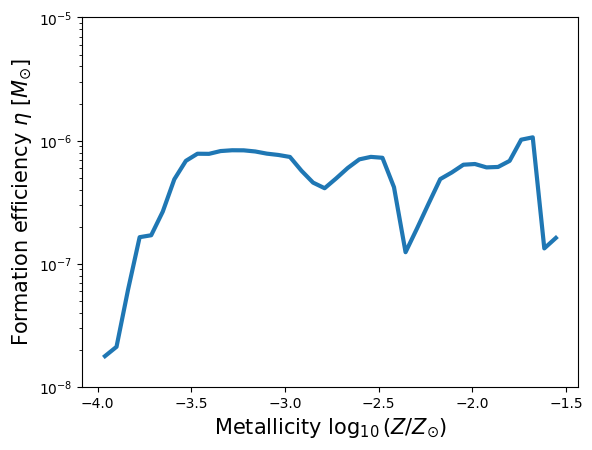

In [23]:
# plotting formation efficencies

# in Floor's notebook she divides the metallicites by 0.0142 - should ask why
hist, bin_edges = np.histogram(np.log10(metallicity_merged_NSNS), weights=formation_efficiencies_NSNS, bins=40, density=True)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
normalization = np.sum(formation_efficiencies_NSNS)

plt.plot(bin_centers, hist*normalization, lw=3)


plt.yscale('log')
plt.ylim(10**-8, 10**-5)

plt.ylabel(r'Formation efficiency $\eta \ [M_{\odot}]$', fontsize=15)
plt.xlabel(r'Metallicity $\log_{10}(Z/Z_{\odot})$', fontsize=15)

In [24]:
# counts_bins_metals/((5e6)*analytical_star_forming_mass_per_binary)

In [25]:
# # different plottin method

# counts_bins_mergers, bin_edges_mergers = np.histogram(np.log10(metallicities_NSNS_DCO_merged), weights=weights_merged, bins=bins_Z_NSNS)
# # left edges + right edges/2 = center of each bin
# center_bins_mergers = (bin_edges_mergers[:-1] + bin_edges_mergers[1:])/2
# # we need to consider the bin width so that if we change the normalization constant, the shape stays the same?
# bin_width_mergers = np.diff(bin_edges_mergers)

# plt.step(center_bins_mergers, counts_bins_mergers/bin_width_mergers, where='mid')
# plt.xlabel(r"$\mathrm{Log_{10}}(\mathrm{Z)}$")
# plt.ylabel(r"Merged Systems")

#### let's do the same for the WDWD systems

In [26]:
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged, stellar_types_2_merged)
carbon_oxygen_bool_WDWD = np.logical_or(ONeCOWD_bool_WDWD,np.logical_or(COONeWD_bool_WDWD,np.logical_or(COHeWD_bool_WDWD,np.logical_or(COWD_bool_WDWD,HeCOWD_bool_WDWD))))

np.sum(carbon_oxygen_bool_WDWD)

np.int64(84885)

In [35]:
print('total DCOs in file = ', len(DCO_mask_NSNS), 'total NSNS we mask = ', np.sum(carbon_oxygen_bool_WDWD)) # to check how many we are cutting :) 

# i think we can just use the metallicities in the DCO table 
metallicity_merged_COWD = metallicity_merged[carbon_oxygen_bool_WDWD]
print('with metallicities = ', metallicity_merged_COWD) # these are not in terms of solar metallicity but just metallicity

total DCOs in file =  1377766 total NSNS we mask =  84885
with metallicities =  [0.00049491 0.00361972 0.00133723 ... 0.00206237 0.01722198 0.00167389]


In [36]:
print(min(metallicity_merged_COWD))
print(max(metallicity_merged_COWD))


0.00010000077326417722
0.029998521294539164


In [28]:
# computing the actual mixture weight
mixture_weights_merged_COWD = mixtrue_weights_merged[carbon_oxygen_bool_WDWD]

formation_efficiencies_COWD = mixture_weights_merged_COWD/total_mass_evolved_compas

Text(0.5, 0, 'Metallicity $\\log_{10}(Z)$')

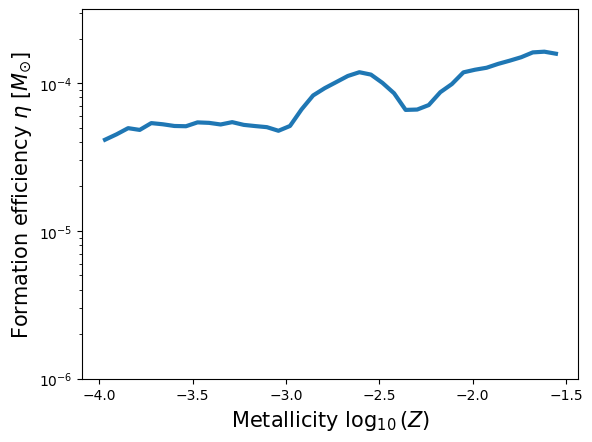

In [37]:
# plotting formation efficencies

# in Floor's notebook she divides the metallicites by 0.0142 - should ask why
hist_COWD, bin_edges_COWD = np.histogram(np.log10(metallicity_merged_COWD), weights=formation_efficiencies_COWD, bins=40, density=True)

bin_centers_COWD = (bin_edges_COWD[0:-1] + bin_edges_COWD[1:])/2
normalization_COWD = np.sum(formation_efficiencies_COWD)

plt.plot(bin_centers_COWD, hist_COWD*normalization_COWD, lw=3)


plt.yscale('log')
plt.ylim(10**-6, 10**-3.5)

plt.ylabel(r'Formation efficiency $\eta \ [M_{\odot}]$', fontsize=15)
plt.xlabel(r'Metallicity $\log_{10}(Z)$', fontsize=15)

### Let's plot both the NSNS and WDWD

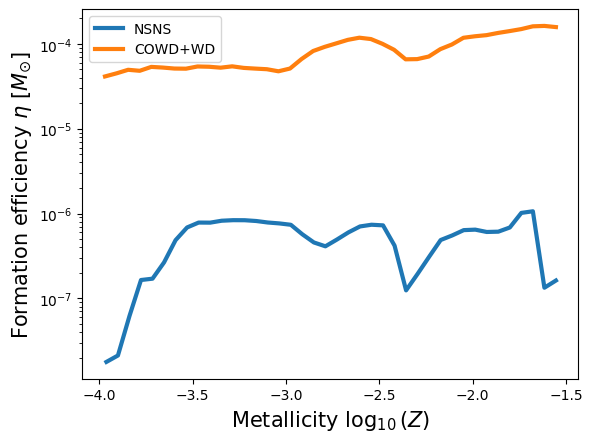

In [38]:
# plotting formation efficencies

# NSNS
hist, bin_edges = np.histogram(np.log10(metallicity_merged_NSNS), weights=formation_efficiencies_NSNS, bins=40, density=True)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
normalization = np.sum(formation_efficiencies_NSNS)

# COWD + WD
hist_COWD, bin_edges_COWD = np.histogram(np.log10(metallicity_merged_COWD), weights=formation_efficiencies_COWD, bins=40, density=True)

bin_centers_COWD = (bin_edges_COWD[0:-1] + bin_edges_COWD[1:])/2
normalization_COWD = np.sum(formation_efficiencies_COWD)

# plotting
plt.plot(bin_centers, hist*normalization, lw=3, label='NSNS')
plt.plot(bin_centers_COWD, hist_COWD*normalization_COWD, lw=3, label='COWD+WD')


plt.yscale('log')
# plt.ylim(10**-6, 10**-3.5)

plt.ylabel(r'Formation efficiency $\eta \ [M_{\odot}]$', fontsize=15)
plt.xlabel(r'Metallicity $\log_{10}(Z)$', fontsize=15)
plt.legend()

In [8]:
# let's read in our files 

## WDWD optimized run

pathToH5_WDWD = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD  = h5.File(pathToH5_WDWD, "r")

DCOs_WDWD = Data_WDWD['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

DATA_SPS_WDWD = Data_WDWD['BSE_System_Parameters']

In [9]:
Data_WDWD.close()

In [97]:
# times (these should be in Myr)
lifetimes_all_WDWD = DCOs_WDWD['Time'][()]
lifetimes_WDWD = lifetimes_all_WDWD[DCO_mask_WDWD]

col_times_all_WDWD = DCOs_WDWD['Coalescence_Time'][()]
col_times_WDWD = col_times_all_WDWD[DCO_mask_WDWD]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times_WDWD = lifetimes_WDWD + col_times_WDWD

condition_mergers_WDWD = delay_times_WDWD < hubble_time
mergers_WDWD = np.sum(condition_mergers_WDWD)

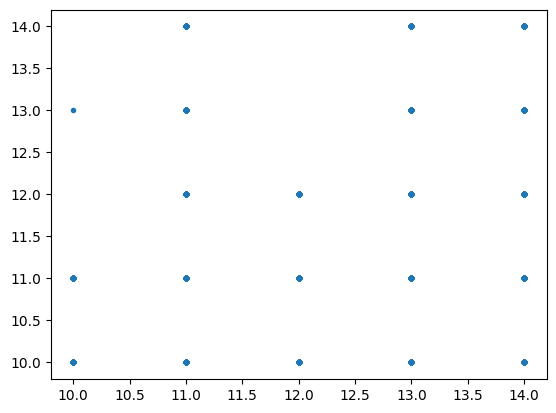

In [98]:
# making sure the DCO is all types
setllar_typesDCO_1 = DCOs_WDWD["Stellar_Type(1)"][()]
setllar_typesDCO_2 = DCOs_WDWD["Stellar_Type(2)"][()]

plt.plot(setllar_typesDCO_1, setllar_typesDCO_2, ".")

In [99]:
stellar_types_all_1_WDWD = DCOs_WDWD['Stellar_Type(1)'][()]
stellar_types_1_WDWD = stellar_types_all_1_WDWD[DCO_mask_WDWD]
stellar_types_1_merged_WDWD = stellar_types_1_WDWD[condition_mergers_WDWD]

stellar_types_all_2_WDWD = DCOs_WDWD['Stellar_Type(2)'][()]
stellar_types_2_WDWD = stellar_types_all_2_WDWD[DCO_mask_WDWD]
stellar_types_2_merged_WDWD = stellar_types_2_WDWD[condition_mergers_WDWD]

In [65]:
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDWD, stellar_types_2_merged_WDWD)
carbon_oxygen_bool_WDWD = np.logical_or(ONeCOWD_bool_WDWD,np.logical_or(COONeWD_bool_WDWD,np.logical_or(COHeWD_bool_WDWD,np.logical_or(COWD_bool_WDWD,HeCOWD_bool_WDWD))))

np.sum(carbon_oxygen_bool_WDWD)

np.int64(112617)

In [101]:
df_SPs_WDWD = pd.DataFrame({key: DATA_SPS_WDWD[key][:] for key in DATA_SPS_WDWD.keys()})

In [103]:
counts_bins_metals_WDWD = pd.cut(np.log10(df_SPs_WDWD['Metallicity@ZAMS(1)']), bins=100).value_counts(sort=False)
counts_bins_metals_WDWD

Metallicity@ZAMS(1)
(-4.002, -3.975]    49783
(-3.975, -3.95]     50397
(-3.95, -3.926]     50435
(-3.926, -3.901]    49987
(-3.901, -3.876]    50457
                    ...  
(-1.647, -1.622]    49867
(-1.622, -1.597]    50040
(-1.597, -1.572]    50066
(-1.572, -1.548]    49595
(-1.548, -1.523]    49626
Name: count, Length: 100, dtype: int64

In [104]:
print(max(Data_WDWD['BSE_System_Parameters']['Mass@ZAMS(1)'][()]))
print(min(Data_WDWD['BSE_System_Parameters']['Mass@ZAMS(1)'][()]))
print(min(Data_WDWD['BSE_System_Parameters']['Mass@ZAMS(2)'][()]))

149.8125979468025
1.0000002299973298
0.10000258026110291


In [105]:
analytical_star_forming_mass_per_binary_WDWD = analytical_star_forming_mass_per_binary_using_kroupa_imf(1, 150, 0.1, fbin=0.7)
analytical_star_forming_mass_per_binary_WDWD

Integrating from 0.01 to 0.08 for fbin = 0.7 and exponent = -0.3
Integrating from 0.08 to 0.5 for fbin = 0.7 and exponent = -1.3
Integrating from 0.5 to 1 for fbin = 0.7 and exponent = -2.3
Integrating from 1 to 10 for fbin = 0.7 and exponent = -2.3
Integrating from 10 to 200 for fbin = 0.7 and exponent = -2.3


13.014304811861441

In [106]:
# we can get the Average_SF_mass_needed to get the number of systems we have
efficencies_perbin_WDWD = counts_bins_metals_WDWD/((5e6)*analytical_star_forming_mass_per_binary_WDWD)

#the centers of each bin
center_bins_WDWD = []
for i in range(len(counts_bins_metals_WDWD)):
    bin_range = str(efficencies_perbin_WDWD.index[i]).strip('(]').split(',')
    left_edge = float(bin_range[0])
    right_edge = float(bin_range[1])

    bin_centers_int = (left_edge + right_edge) / 2
    center_bins_WDWD.append(bin_centers_int)


Text(0.5, 0, 'Metallicity $\\log_{10}(Z/Z_{\\odot})$')

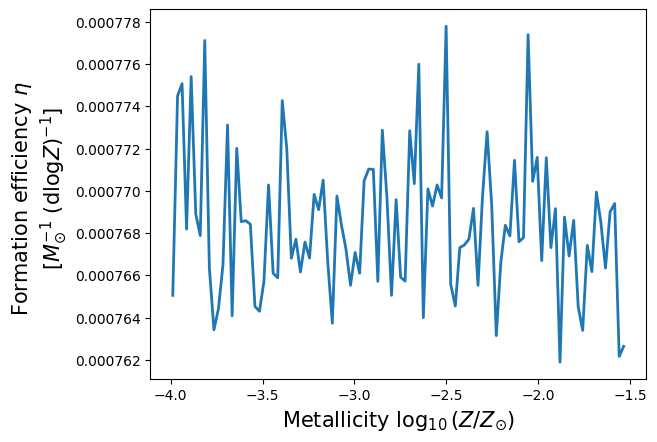

In [133]:
# let's actually plot this
plt.plot(center_bins_WDWD, efficencies_perbin_WDWD.values, lw=2)


# plt.yscale('log')
# plt.ylim(7e-4, 9e-4)

plt.ylabel('Formation efficiency $\eta$  \n  $[M_{\odot}^{-1} \ (\mathrm{dlog}Z)^{-1}]$', fontsize=15)
plt.xlabel(r'Metallicity $\log_{10}(Z/Z_{\odot})$', fontsize=15)



Text(0.5, 0, 'Metallicity $\\log_{10}(Z/Z_{\\odot})$')

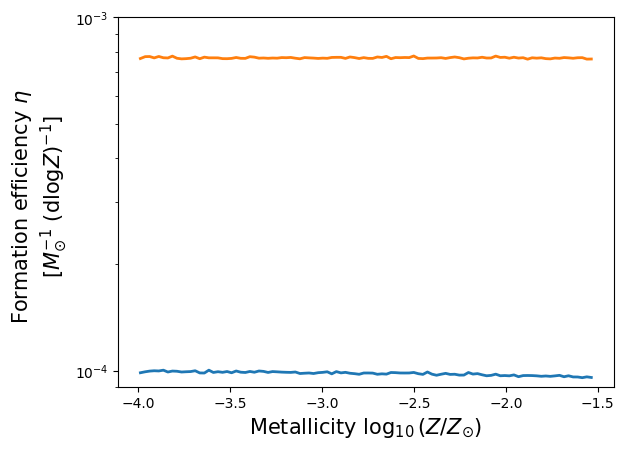

In [120]:
# let's now show both formation efficencies overplotted

plt.plot(center_bins, efficencies_perbin.values, lw=2)
plt.plot(center_bins_WDWD, efficencies_perbin_WDWD.values, lw=2)
4
plt.yscale('log')
plt.ylim(9e-5, 10**-3)

plt.ylabel('Formation efficiency $\eta$  \n  $[M_{\odot}^{-1} \ (\mathrm{dlog}Z)^{-1}]$', fontsize=15)
plt.xlabel(r'Metallicity $\log_{10}(Z/Z_{\odot})$', fontsize=15)

In [47]:
Data_NSNS.close()